<details>
  <summary><strong>MIT License (click to expand)</strong></summary>

  <pre>
MIT License
Copyright (c) 2023-2026 AI Course Notebook Contributors
Repository: https://github.com/arch-inform-kaken-group/ai-course-notebooks

Permission is hereby granted, free of charge, to any person obtaining a copy
of this software and associated documentation files (the "Software"), to deal
in the Software without restriction, including without limitation the rights
to use, copy, modify, merge, publish, distribute, sublicense, and/or sell
copies of the Software, and to permit persons to whom the Software is
furnished to do so, subject to the following conditions:

The above copyright notice and this permission notice shall be included in all
copies or substantial portions of the Software.

THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR
IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY,
FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE
AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER
LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING FROM,
OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER DEALINGS IN THE
SOFTWARE.
  </pre>
</details>


# Support Vector Machines: A Hands-On Intuition
### Finding the *widest street* between two classes

This notebook is a short, visual introduction to **Support Vector Machines (SVMs)**.

We build the intuition in three steps:

1. **The margin**: an SVM draws the boundary that leaves the *widest possible gap* between the two classes.
2. **The kernel trick**: when a straight line can't separate the data, the SVM *bends space* so that it can.
3. **Why it works**: we *lift* the data into 3D and watch a flat plane do the job.

> Mental model: a good fence between two herds is not just *any* line. It is the line that
> stays as far as possible from the nearest animal on each side.


# Part 0: Setup

In [1]:
# Setup: all of this is pre-installed on Colab
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm
from sklearn.datasets import make_blobs, make_circles
from sklearn.model_selection import train_test_split

np.random.seed(0)
plt.rcParams["figure.figsize"] = (6, 5)
print("Ready.")

Ready.


## Part 1: The maximum-margin idea

We start with two clearly separated groups of points (two classes).
Many straight lines could separate them, but the SVM picks **one specific line**:
the one that sits in the middle of the *widest empty street* between the classes.

- The solid line is the **decision boundary**.
- The dashed lines mark the edges of the **margin** (the "street").
- The **circled points** are the **support vectors**, the only points that touch the street
  and actually *define* the boundary. Every other point could move freely without changing it.

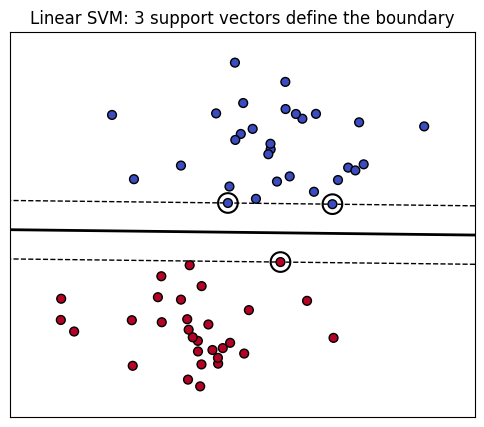

This boundary is supported by only 3 of the 60 points.


In [2]:
# Two well-separated classes
X, y = make_blobs(n_samples=60, centers=2, random_state=6, cluster_std=1.2)

clf = svm.SVC(kernel="linear", C=1000)   # large C -> hard margin
clf.fit(X, y)

# Plot points
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", s=40, edgecolors="k", zorder=3)

# Draw boundary (level 0) and margins (levels -1, +1)
xx = np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 200)
yy = np.linspace(X[:, 1].min() - 1, X[:, 1].max() + 1, 200)
XX, YY = np.meshgrid(xx, yy)
Z = clf.decision_function(np.c_[XX.ravel(), YY.ravel()]).reshape(XX.shape)
plt.contour(XX, YY, Z, levels=[-1, 0, 1],
            linestyles=["--", "-", "--"], colors="k", linewidths=[1, 2, 1])

# Highlight the support vectors
sv = clf.support_vectors_
plt.scatter(sv[:, 0], sv[:, 1], s=200, facecolors="none",
            edgecolors="k", linewidths=1.5, zorder=2)

plt.title(f"Linear SVM: {len(sv)} support vectors define the boundary")
plt.xticks([]); plt.yticks([]); plt.show()

print(f"This boundary is supported by only {len(sv)} of the {len(X)} points.")

## Part 2: Soft margin and the `C` knob

Real data is messy and the classes overlap. The SVM then allows a few points to sit inside
the street (or on the wrong side). The **`C`** parameter controls the trade-off:

- **Small `C`** → a *wider* street, more tolerant of mistakes → simpler, more robust.
- **Large `C`** → a *narrower* street that tries hard to classify every point → can overfit.

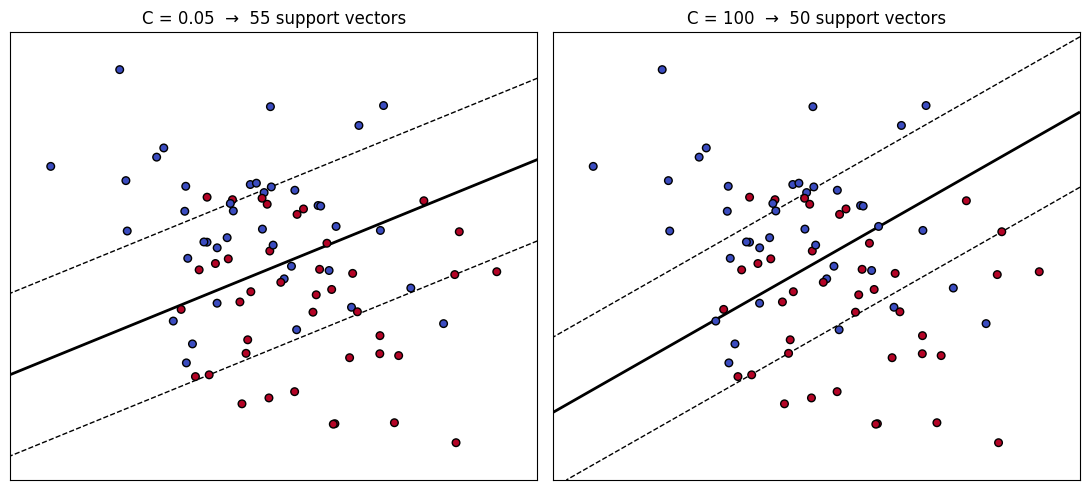

In [3]:
# Slightly overlapping classes
Xs, ys = make_blobs(n_samples=80, centers=2, random_state=0, cluster_std=2.0)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, C in zip(axes, [0.05, 100]):
    m = svm.SVC(kernel="linear", C=C).fit(Xs, ys)
    ax.scatter(Xs[:, 0], Xs[:, 1], c=ys, cmap="coolwarm", s=30, edgecolors="k", zorder=3)
    xx = np.linspace(Xs[:, 0].min()-1, Xs[:, 0].max()+1, 200)
    yy = np.linspace(Xs[:, 1].min()-1, Xs[:, 1].max()+1, 200)
    XX, YY = np.meshgrid(xx, yy)
    Z = m.decision_function(np.c_[XX.ravel(), YY.ravel()]).reshape(XX.shape)
    ax.contour(XX, YY, Z, levels=[-1, 0, 1], linestyles=["--","-","--"],
               colors="k", linewidths=[1,2,1])
    ax.set_title(f"C = {C}  →  {len(m.support_vectors_)} support vectors")
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

The small-`C` model keeps a wide, calm street; the large-`C` model squeezes the street to
chase individual points. Choosing `C` (usually by cross-validation) is one of the few knobs
you tune on an SVM.

## Part 3: The kernel trick

Now the hard case. The data below is **two concentric rings**: an inner blob surrounded by an
outer ring. **No straight line can separate them.** Watch a linear SVM fail, then swap in an
**RBF kernel** and watch it succeed with a curved boundary, *without us drawing that curve by hand.*

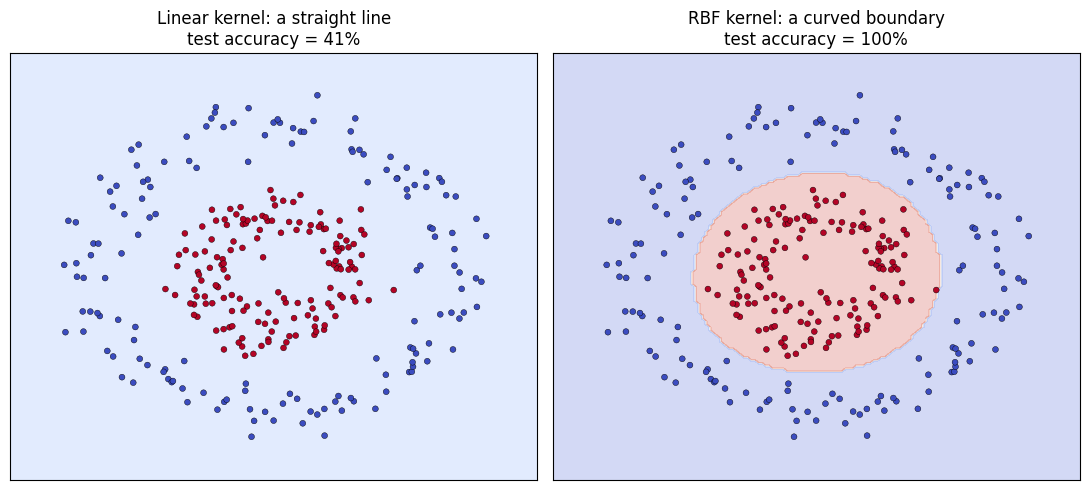

In [4]:
# Inner circle vs outer ring (NOT linearly separable)
Xc, yc = make_circles(n_samples=300, factor=0.4, noise=0.10, random_state=0)
Xtr, Xte, ytr, yte = train_test_split(Xc, yc, test_size=0.3, random_state=0)

def show_boundary(ax, model, title):
    model.fit(Xtr, ytr)
    acc = model.score(Xte, yte)
    xx, yy = np.meshgrid(np.arange(Xc[:,0].min()-.3, Xc[:,0].max()+.3, .02),
                         np.arange(Xc[:,1].min()-.3, Xc[:,1].max()+.3, .02))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, cmap="coolwarm", alpha=.25)
    ax.scatter(Xc[:,0], Xc[:,1], c=yc, cmap="coolwarm", s=18, edgecolors="k", linewidths=.3)
    ax.set_title(f"{title}\ntest accuracy = {acc:.0%}")
    ax.set_xticks([]); ax.set_yticks([])

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
show_boundary(axes[0], svm.SVC(kernel="linear"),            "Linear kernel: a straight line")
show_boundary(axes[1], svm.SVC(kernel="rbf", gamma="scale"), "RBF kernel: a curved boundary")
plt.tight_layout(); plt.show()

The linear kernel scores near chance, because there is simply no straight line that works.
The **same algorithm** with an **RBF kernel** wraps a closed curve around the inner blob and
classifies almost everything correctly. The kernel let the SVM behave as if it were working in
a higher-dimensional space, where the rings *are* separable.

## Part 4: Why it works, by lifting the data into 3D

Here is the intuition behind the kernel trick, made literal. We add a third coordinate to every
point: **z = x² + y²** (how far the point is from the centre). The inner blob (small radius)
stays **low**; the outer ring (large radius) floats **up**. Now a simple **flat plane** slips
between them. The curved 2D boundary is just a flat cut seen from above.

The cell below renders an **interactive 3D plot** (*drag to rotate, scroll to zoom*).
Plotly is pre-installed on Colab, so no setup is required.

In [5]:
import plotly.graph_objects as go

z = Xc[:, 0]**2 + Xc[:, 1]**2          # the lift: distance from centre, squared

fig = go.Figure()

# Points: same colour scheme as the 2D figure above
fig.add_trace(go.Scatter3d(
    x=Xc[:, 0], y=Xc[:, 1], z=z, mode="markers",
    marker=dict(size=4.5, color=yc,
                colorscale=[[0, "#3b78b5"], [1, "#c8413c"]],
                line=dict(width=0.4, color="black"), showscale=False),
    showlegend=False,
    hovertemplate="(%{x:.2f}, %{y:.2f})  z=%{z:.2f}<extra></extra>",
))

# Separating plane at z = 0.5
fig.add_trace(go.Mesh3d(
    x=[-1.2,  1.2,  1.2, -1.2],
    y=[-1.2, -1.2,  1.2,  1.2],
    z=[0.5,   0.5,  0.5,  0.5],
    i=[0, 0], j=[1, 2], k=[2, 3],
    opacity=0.35, color="#888888",
    flatshading=True, hoverinfo="skip", showlegend=False,
))

fig.update_layout(
    title=dict(text="Lift to 3D:  z = x² + y²    <i>(drag to rotate, scroll to zoom)</i>",
               x=0.5, font=dict(size=15)),
    scene=dict(
        xaxis=dict(title="x", showticklabels=False),
        yaxis=dict(title="y", showticklabels=False),
        zaxis=dict(title="z"),
        camera=dict(eye=dict(x=1.55, y=1.55, z=0.55)),
        aspectmode="cube",
    ),
    width=720, height=560, margin=dict(l=0, r=0, t=40, b=0),
)
fig.show()

!mkdir -p plots
fig.write_html("./plots/2026_ex03_SVM_3d_en.html", include_plotlyjs=True,full_html=True, auto_open=False)

print("Inner blob (red) sits low, outer ring (blue) lifts up, so a flat plane now separates them.")

Inner blob (red) sits low, outer ring (blue) lifts up, so a flat plane now separates them.


<div class="sphinx-only" style="display:none">
  <iframe
    src="../_static/plotly/2026_ex03_SVM_3d_en.html"
    width="100%"
    height="760"
    style="border:0;"
  ></iframe>
</div>

If the graph is not displayed: [Open the PNG file on GitHub](https://github.com/arch-inform-kaken-group/ai-course-notebooks/tree/main/notebooks/en_2026/plots/2026_ex03_SVM_3d_en.png)

## Summary

| Idea | What the SVM does |
|------|-------------------|
| **Maximum margin** | Picks the boundary with the widest gap to the nearest points. |
| **Support vectors** | Only the closest points define the boundary; the rest don't matter. |
| **Soft margin (`C`)** | Trades street width against a few misclassifications. |
| **Kernel trick** | Bends space so curved boundaries become straight, with no manual feature engineering. |

**Where this goes next (optional, heavier examples):**
- **Faces** (eigenfaces + SVM on real photos):
  https://scikit-learn.org/1.6/auto_examples/applications/plot_face_recognition.html
- **Many kernels side by side**:
  https://scikit-learn.org/1.6/auto_examples/svm/plot_svm_kernels.html
- **SVM vs other classifiers**:
  https://scikit-learn.org/1.6/auto_examples/classification/plot_classifier_comparison.html

SVMs remain a strong, well-understood baseline, especially when you have **limited data**,
**many features**, and a need for a **clear, robust boundary**.

<br>

## Sources & References

*Datasets in this notebook are synthetic, generated in code by scikit-learn (`make_blobs`,
`make_circles`). Nothing is downloaded. The 3D "lift" figure (z = x² + y²) is an original
illustration of the kernel-trick concept.*

---
**[Library]**
- scikit-learn (BSD-3-Clause License): https://scikit-learn.org/

**[Datasets (synthetic, generated in code)]**
- `sklearn.datasets.make_blobs`: https://scikit-learn.org/1.6/modules/generated/sklearn.datasets.make_blobs.html
- `sklearn.datasets.make_circles`: https://scikit-learn.org/1.6/modules/generated/sklearn.datasets.make_circles.html

**[Sample Code / Examples]**
- scikit-learn, [SVM: Maximum margin separating hyperplane](https://scikit-learn.org/1.6/auto_examples/svm/plot_separating_hyperplane.html), basis for the margin and support-vector plot (Part 1)
- scikit-learn, [Plot classification boundaries with different SVM Kernels](https://scikit-learn.org/1.6/auto_examples/svm/plot_svm_kernels.html), basis for the linear-vs-RBF comparison (Part 3)

**[Papers]**
- C. Cortes and V. Vapnik, [Support-Vector Networks](https://doi.org/10.1007/BF00994018), *Machine Learning*, 20(3):273-297, 1995
- B. E. Boser, I. M. Guyon and V. N. Vapnik, [A Training Algorithm for Optimal Margin Classifiers](https://doi.org/10.1145/130385.130401), *Proceedings of the Fifth Annual Workshop on Computational Learning Theory (COLT '92)*, pp. 144-152, 1992
- F. Pedregosa et al., [Scikit-learn: Machine Learning in Python](https://jmlr.org/papers/v12/pedregosa11a.html), *Journal of Machine Learning Research*, 12:2825-2830, 2011
- C.-C. Chang and C.-J. Lin, [LIBSVM: A Library for Support Vector Machines](https://doi.org/10.1145/1961189.1961199), *ACM Transactions on Intelligent Systems and Technology*, 2(3):27, 2011 (the solver behind `SVC`)